### 🔥 Temperature Prediction

This notebook forecasts Australia's national mean temperature using historical climate trends and machine learning. Results will help assess future climate risk and habitability.


In [148]:
import pandas as pd
import os

FINAL_DATASET_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\final_dataset"

df = pd.read_csv(os.path.join(FINAL_DATASET_DIR, "australia_climate_ml_ready.csv"))
print(df)

    Year  Mean_Temperature  Rainfall (mm)  Rainfall Anomaly (mm)  \
0   2001         21.858513         542.80                  76.76   
1   2002         21.858513         332.54                -133.49   
2   2003         21.858513         469.91                   3.88   
3   2004         21.858513         491.58                  25.55   
4   2005         21.858513         394.30                 -71.74   
5   2006         21.858513         482.06                  16.02   
6   2007         21.858513         495.65                  29.61   
7   2008         21.858513         471.42                   5.39   
8   2009         21.858513         452.69                 -13.35   
9   2010         21.858513         683.70                 217.66   
10  2011         22.165803         696.70                 230.66   
11  2012         22.165803         471.84                   5.80   
12  2013         22.165803         422.61                 -43.42   
13  2014         22.165803         473.38       

### 📈 Predicting Each Climate Trend Individually

To maximize historical coverage and forecast reliability, we will first model each major climate trend—beginning with temperature—using its own full time series, rather than only the years shared across all datasets.


In [149]:
TEMP_DATASET_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data\temp"
temp_df = pd.read_csv(os.path.join(TEMP_DATASET_DIR, "aus_mean_temp.csv"))
print(temp_df)

       Decade  Mean_Temperature
0   1911-1920         21.218677
1   1921-1930         21.150766
2   1931-1940         21.200029
3   1941-1950         21.075919
4   1951-1960         21.196777
5   1961-1970         21.287564
6   1971-1980         21.398203
7   1981-1990         21.582206
8   1991-2000         21.620416
9   2001-2010         21.858513
10  2011-2020         22.165803


In [150]:
# Decade to "Year" conversion

annual_rows = []
for idx, row in temp_df.iterrows():
    decade_str = row["Decade"]
    start_year, end_year = [int(x) for x in decade_str.split("-")]
    for y in range(start_year, end_year + 1):
        annual_rows.append({
            "Year": y,
            "Mean_Temperature": row["Mean_Temperature"]
        })
annual_temp_df = pd.DataFrame(annual_rows)
print(annual_temp_df)

     Year  Mean_Temperature
0    1911         21.218677
1    1912         21.218677
2    1913         21.218677
3    1914         21.218677
4    1915         21.218677
..    ...               ...
105  2016         22.165803
106  2017         22.165803
107  2018         22.165803
108  2019         22.165803
109  2020         22.165803

[110 rows x 2 columns]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              110 non-null    int64  
 1   Mean_Temperature  110 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.8 KB
None


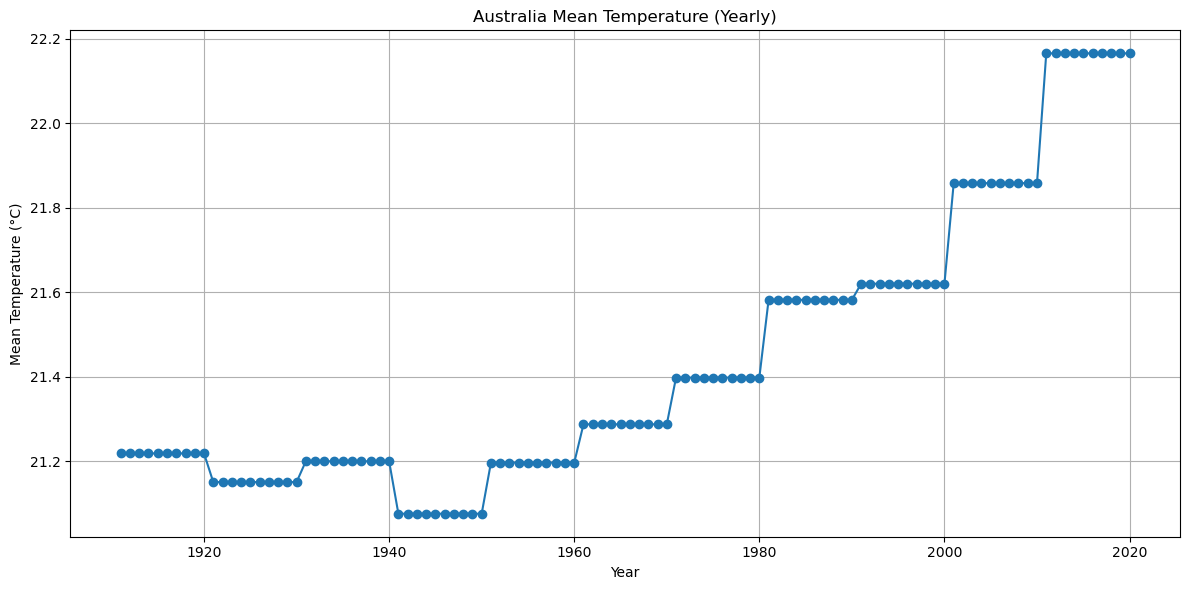

In [151]:
import matplotlib.pyplot as plt

print(annual_temp_df.info())

plt.figure(figsize=(12, 6))
plt.plot(annual_temp_df["Year"], annual_temp_df["Mean_Temperature"], marker='o')
plt.title("Australia Mean Temperature (Yearly)")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [152]:
# Augmented Dickey-Fuller test for stationarity (trying statsmodels library for the first time)

from statsmodels.tsa.stattools import adfuller

result = adfuller(annual_temp_df["Mean_Temperature"])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
if result[1] < 0.05:
    print("Series is stationary (reject null hypothesis)")
else:
    print("Series is not stacionary (fail to reject null hypothesis)")

ADF Statistic: 1.5378793309822176
p-value: 0.997658706813307
Series is not stacionary (fail to reject null hypothesis)


In [153]:
annual_temp_df["Diff_Temp"] = annual_temp_df["Mean_Temperature"].diff()

# Wanted to check ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1,1,0) already does first differencing internally
model_arima = ARIMA(annual_temp_df["Mean_Temperature"], order=(1,1,0)).fit()
future_pred_arima = model_arima.forecast(steps=50)
print(future_pred_arima)

110    22.165803
111    22.165803
112    22.165803
113    22.165803
114    22.165803
115    22.165803
116    22.165803
117    22.165803
118    22.165803
119    22.165803
120    22.165803
121    22.165803
122    22.165803
123    22.165803
124    22.165803
125    22.165803
126    22.165803
127    22.165803
128    22.165803
129    22.165803
130    22.165803
131    22.165803
132    22.165803
133    22.165803
134    22.165803
135    22.165803
136    22.165803
137    22.165803
138    22.165803
139    22.165803
140    22.165803
141    22.165803
142    22.165803
143    22.165803
144    22.165803
145    22.165803
146    22.165803
147    22.165803
148    22.165803
149    22.165803
150    22.165803
151    22.165803
152    22.165803
153    22.165803
154    22.165803
155    22.165803
156    22.165803
157    22.165803
158    22.165803
159    22.165803
Name: predicted_mean, dtype: float64


In [154]:
# New Index for forecast years
last_year = annual_temp_df.index.max() if annual_temp_df.index.name == "Year" else annual_temp_df["Year"].max()
forecast_years = range(last_year + 1, last_year + 1 + 50)
future_pred_arima.index = forecast_years

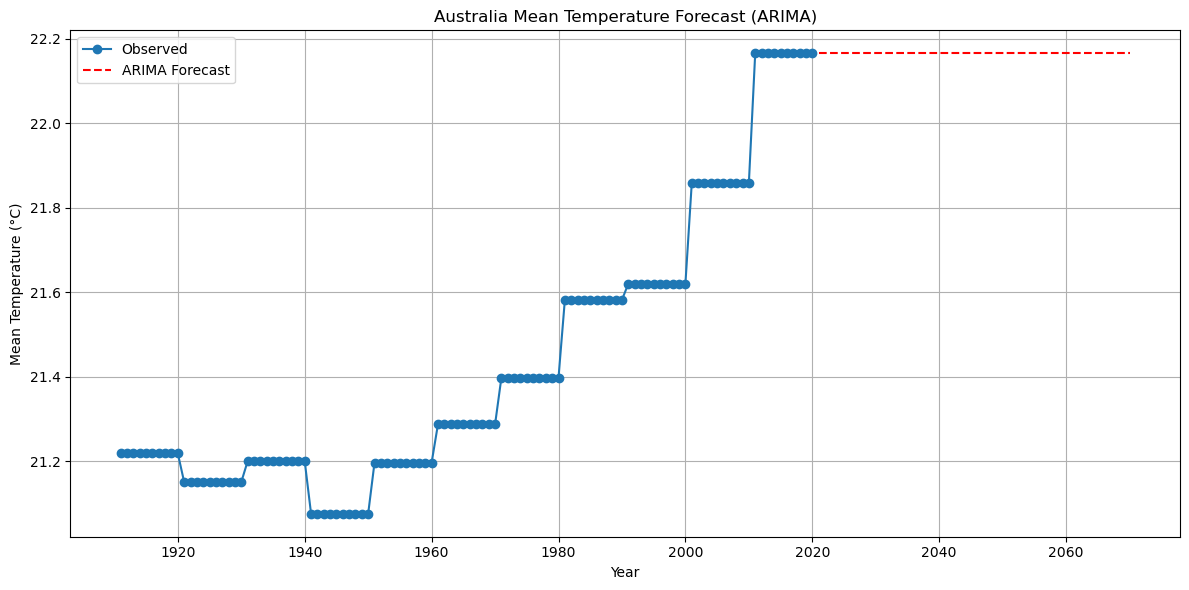

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(annual_temp_df["Year"], annual_temp_df["Mean_Temperature"], marker="o", label="Observed")
plt.plot(future_pred_arima.index, future_pred_arima, "r--", label="ARIMA Forecast")
plt.title("Australia Mean Temperature Forecast (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

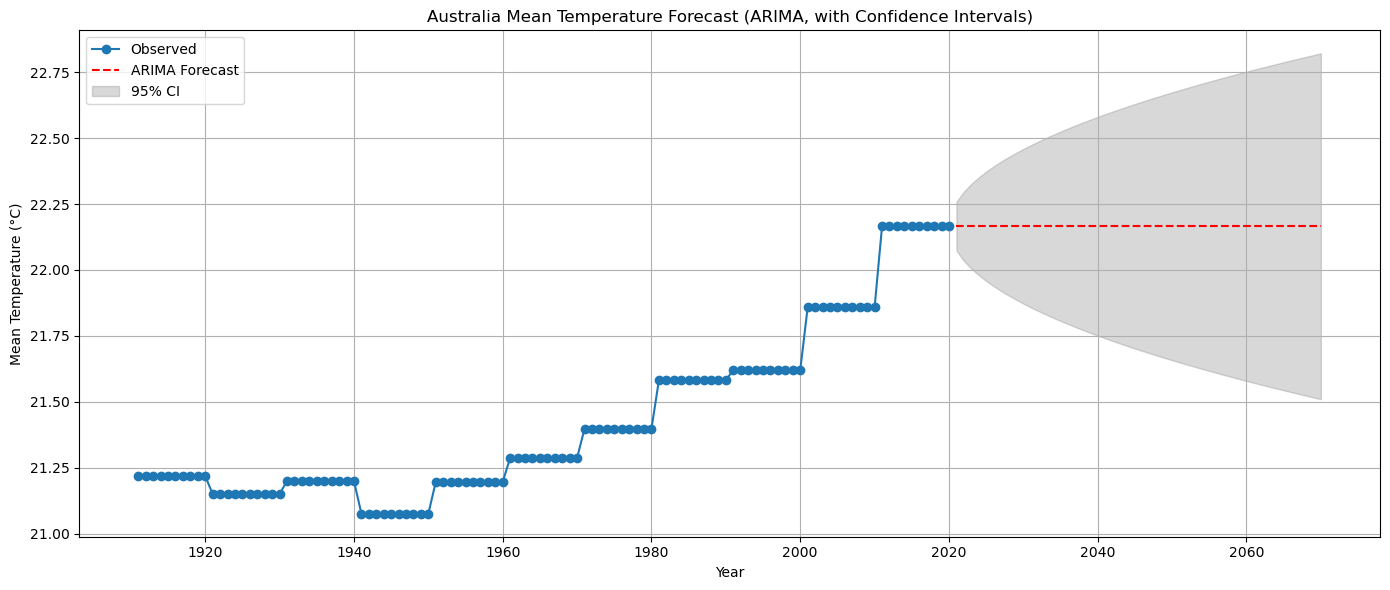

In [156]:
pred_obj = model_arima.get_forecast(steps=50)
ci = pred_obj.conf_int(alpha=0.05)
plt.figure(figsize=(14,6))
plt.plot(annual_temp_df["Year"], annual_temp_df["Mean_Temperature"], marker='o', label="Observed")
plt.plot(forecast_years, future_pred_arima, 'r--', label="ARIMA Forecast")
plt.fill_between(forecast_years, ci.iloc[:,0], ci.iloc[:,1], color='gray', alpha=0.3, label="95% CI")
plt.title("Australia Mean Temperature Forecast (ARIMA, with Confidence Intervals)")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


> ⚠️ ARIMA did not produce a realistic forecast here due to the “stepwise” nature of the decadal input data and the strong upward trend.  
> For this type of data, **linear regression or exponential smoothing** will give more reliable future temperature projections.


#### Quick exploration for getting the overall trend.

In [157]:
import numpy as np
from sklearn.linear_model import LinearRegression

print(annual_temp_df)

X = annual_temp_df["Year"].values.reshape(-1, 1)
y = annual_temp_df["Mean_Temperature"].values

model = LinearRegression()
model.fit(X, y)

     Year  Mean_Temperature  Diff_Temp
0    1911         21.218677        NaN
1    1912         21.218677        0.0
2    1913         21.218677        0.0
3    1914         21.218677        0.0
4    1915         21.218677        0.0
..    ...               ...        ...
105  2016         22.165803        0.0
106  2017         22.165803        0.0
107  2018         22.165803        0.0
108  2019         22.165803        0.0
109  2020         22.165803        0.0

[110 rows x 3 columns]


LinearRegression()

In [158]:
# Forecast for the next 50 years
future_years = np.arange(annual_temp_df["Year"].max() + 1, annual_temp_df["Year"].max() + 51)
future_X = future_years.reshape(-1, 1)
future_pred = model.predict(future_X)
print(future_pred)

[21.93476859 21.94382278 21.95287697 21.96193116 21.97098535 21.98003954
 21.98909373 21.99814792 22.00720211 22.0162563  22.02531049 22.03436468
 22.04341887 22.05247306 22.06152725 22.07058144 22.07963564 22.08868983
 22.09774402 22.10679821 22.1158524  22.12490659 22.13396078 22.14301497
 22.15206916 22.16112335 22.17017754 22.17923173 22.18828592 22.19734011
 22.2063943  22.21544849 22.22450268 22.23355687 22.24261106 22.25166525
 22.26071944 22.26977363 22.27882782 22.28788201 22.2969362  22.30599039
 22.31504458 22.32409877 22.33315296 22.34220715 22.35126134 22.36031553
 22.36936972 22.37842391]


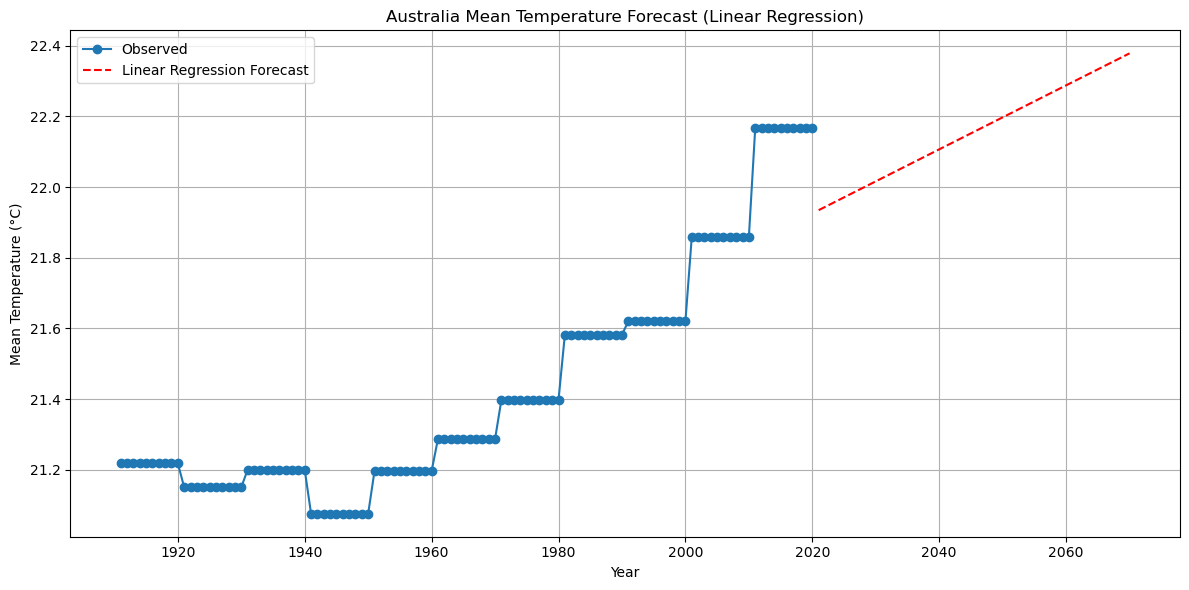

In [159]:
# Plotting the linear regression forecast
plt.figure(figsize=(12, 6))
plt.plot(annual_temp_df["Year"], annual_temp_df["Mean_Temperature"], marker="o", label="Observed")
plt.plot(future_years, future_pred, "r--", label="Linear Regression Forecast")
plt.title("Australia Mean Temperature Forecast (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
# Show model parameters
print(f"Trend: {model.coef_[0]:.3f} °C/year")
print(f"Intercept: {model.intercept_:.2f}")

Trend: 0.009 °C/year
Intercept: 3.64


### 🔥 Predicting and Forecasting Australia’s Annual Mean Temperature

We use linear regression to model and forecast national mean temperature, first evaluating model accuracy with a train/test split, then using all available data for a future forecast.


In [161]:
from sklearn.metrics import mean_squared_error, r2_score


split_year = 2005
train = annual_temp_df[annual_temp_df["Year"] <= split_year]
test = annual_temp_df[annual_temp_df["Year"] > split_year]

X_train = train["Year"].values.reshape(-1, 1)
y_train = train["Mean_Temperature"].values
X_test = test["Year"].values.reshape(-1, 1)
y_test = test["Mean_Temperature"].values

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [162]:
mse = mean_squared_error(y_test, y_pred)
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")


Test RMSE: 0.384
Test R²: -6.044


An R² of -6.044 means my model is not capturing the trend in the test data at all and is performing much worse than a naive mean prediction.

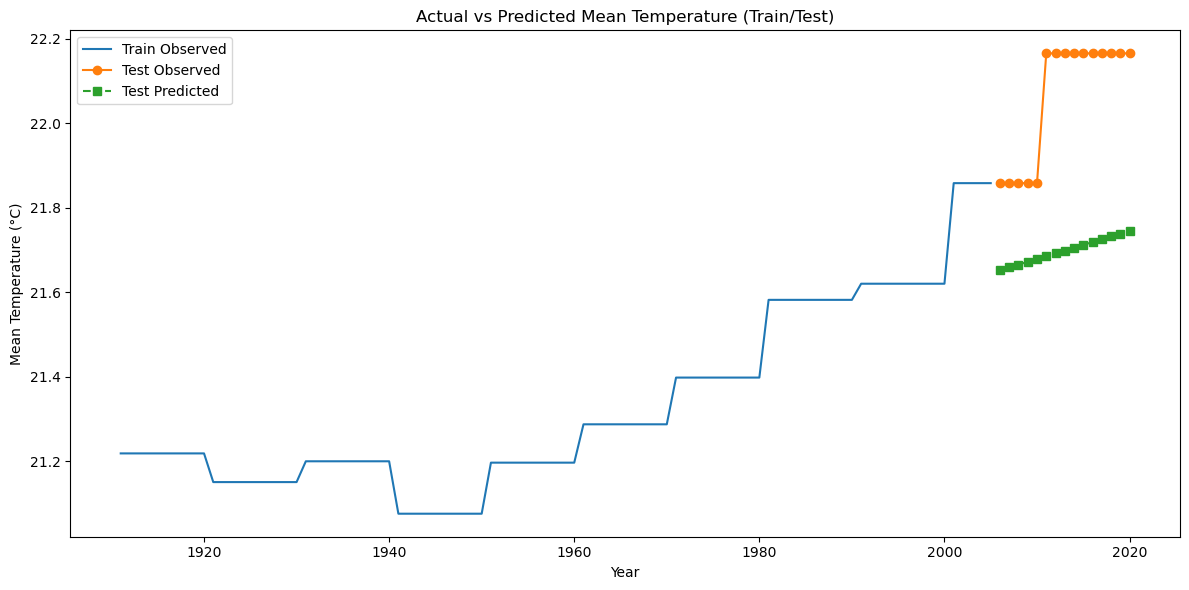

In [163]:
plt.figure(figsize=(12,6))
plt.plot(train["Year"], y_train, label="Train Observed")
plt.plot(test["Year"], y_test, label="Test Observed", marker="o")
plt.plot(test["Year"], y_pred, label="Test Predicted", marker="s", linestyle='--')
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.title("Actual vs Predicted Mean Temperature (Train/Test)")
plt.legend()
plt.tight_layout()
plt.show()

#### 📌 Why Predict Annual Mean Temperature Instead of Decadal Means?

In this notebook, we focus on predicting the **mean temperature for each year**, rather than using decadal averages. It’s turning out to be quite a bit more difficult than I expected to find the average annual temperature for each year. The average per decade is easier to find, but it provides much less precision for predictions.

In [164]:
final_temp_df = pd.read_csv(os.path.join(TEMP_DATASET_DIR, "final_mean_temp.csv"))

print(final_temp_df)

     Year  Rank  High_Mean_C  Low_Mean_C  Mean_Temperature
0    2021    16         29.0        15.2             22.10
1    2020     3         29.5        15.7             22.60
2    2019     1         30.1        15.5             22.80
3    2018     5         29.7        15.3             22.50
4    2017     5         29.6        15.4             22.50
..    ...   ...          ...         ...               ...
116  1905   102         28.3        14.1             21.20
117  1904   105         28.1        14.2             21.15
118  1903   100         28.1        14.3             21.20
119  1902    60         28.8        14.3             21.55
120  1901    55         28.6        14.6             21.60

[121 rows x 5 columns]


In [165]:
final_temp_df["Year"] = pd.to_datetime(final_temp_df["Year"], format="%Y")
final_temp_df = final_temp_df.set_index("Year")
final_temp_df = final_temp_df.sort_index() 
final_temp_df = final_temp_df.asfreq('YS')  # 'YS' = Year Start

In [166]:
split_year = 2005  # Train on 1901-2005, test on 2006 onwards
train = final_temp_df.loc[:f"{split_year}"]
test = final_temp_df.loc[str(int(split_year) + 1):]

X = final_temp_df.index.year.values.reshape(-1, 1)
y = final_temp_df["Mean_Temperature"].values


In [167]:
# Linear Regression model

X_train = train.index.year.values.reshape(-1, 1)
y_train = train["Mean_Temperature"].values
X_test = test.index.year.values.reshape(-1, 1)
y_test = test["Mean_Temperature"].values

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [168]:
# Metrics rmse and r2
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Test RMSE: {rmse:.3f}")
print(f"Linear Regression Test R2: {r2:.3f}")



Linear Regression Test RMSE: 0.495
Linear Regression Test R2: -0.354


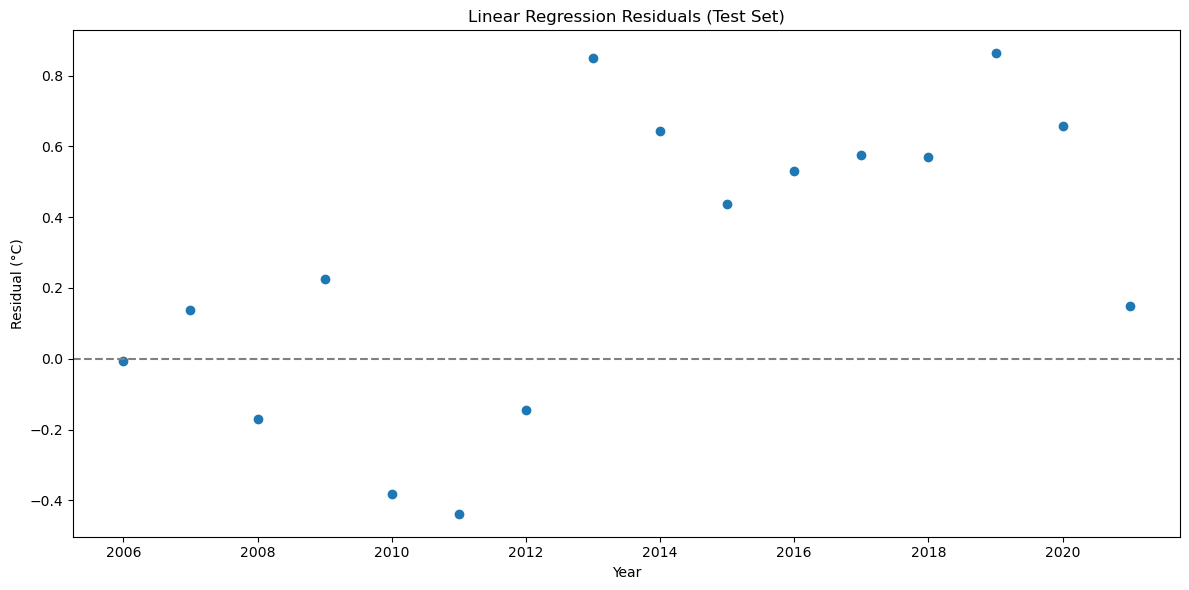

In [169]:
# Residuals
residuals = y_test - y_pred

# Plotting Residuals
plt.figure(figsize=(12, 6))
plt.scatter(test.index.year.values.reshape(-1, 1), residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Linear Regression Residuals (Test Set)")
plt.xlabel("Year")
plt.ylabel("Residual (°C)")
plt.tight_layout()
plt.show()

#### 📊 Linear Regression Results on Annual Mean Temperature

Using the new annual mean temperature dataset (`final_temp_df`), I trained a linear regression model to predict Australia’s national mean temperature. The model’s performance was evaluated using RMSE and R² metrics, as well as a residuals plot.

- **RMSE** quantifies the average prediction error in °C; lower values indicate better accuracy.
- **R²** shows how much of the temperature variation is explained by the model; values closer to 1 are better.
- The **residuals plot** helps check for patterns or outliers in the prediction errors.

These results provide insight into how well a simple linear trend captures Australia’s annual temperature changes and highlight areas where the model may be improved.

#### 📝 Conclusion: Linear Regression for Annual Mean Temperature

The linear regression model applied to the annual mean temperature data did not perform well, as indicated by a low (or negative) R² and a relatively high RMSE. This suggests that a simple linear trend is not sufficient to capture the complexity and variability in Australia’s yearly temperature changes. More advanced or flexible modeling approaches may be needed to improve prediction accuracy and better reflect the underlying climate dynamics.

In [171]:
# Exponential Smoothing model (Holt's Linear Trend Method)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(train["Mean_Temperature"], trend="add", seasonal=None).fit()
y_pred_holt = holt_model.forecast(len(test))

# Metrics for Holt's model
rmse_holt = np.sqrt(mean_squared_error(y_test, y_pred_holt))
r2_holt = r2_score(y_test, y_pred_holt)

print(f"Exp Smoothing Test RMSE: {rmse_holt:.3f}")
print(f"Exp Smoothing Test R2: {r2_holt:.3f}")


Exp Smoothing Test RMSE: 0.379
Exp Smoothing Test R2: 0.205


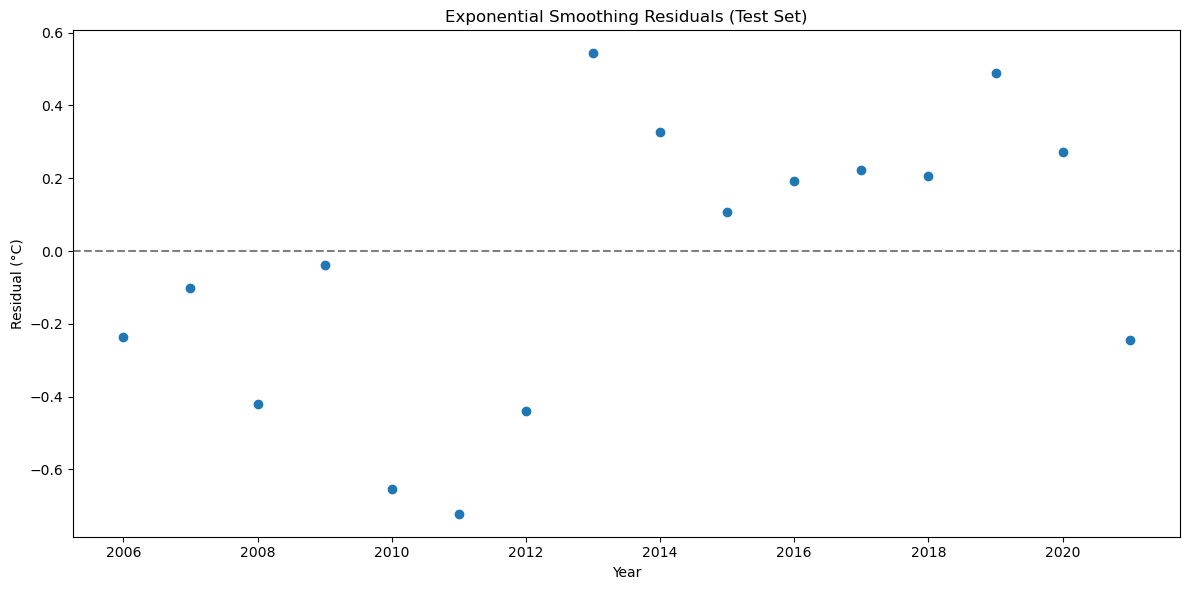

In [172]:
# Residuals for Holt's model
residuals_holt = y_test - y_pred_holt

# Plotting Holt's model predictions
plt.figure(figsize=(12, 6))
plt.scatter(test.index.year.values.reshape(-1, 1), residuals_holt)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Exponential Smoothing Residuals (Test Set)")
plt.xlabel("Year")
plt.ylabel("Residual (°C)")
plt.tight_layout()
plt.show()


#### 📊 Exponential Smoothing Results on Annual Mean Temperature

Using Holt’s Exponential Smoothing, the model achieved an RMSE of **0.379 °C** and an R² of **0.205** on the test set. This indicates a moderate prediction error and that about 20% of the year-to-year temperature variation is explained by the model. While this is an improvement over linear regression, it suggests that further enhancements or more advanced models may be needed to better capture the complexity of Australia’s annual temperature trends.

The residuals plot for Holt’s model shows how prediction errors vary by year. Most points are close to zero, but some years have larger errors, indicating the model captures the general trend but misses some year-to-year fluctuations.

In [173]:
# ARIMA model
from statsmodels.tsa.arima.model import ARIMA 

arima_model = ARIMA(train["Mean_Temperature"], order=(1, 1, 0)).fit()
y_pred_arima = arima_model.forecast(steps=len(test))


In [174]:
# Metrics for ARIMA model
rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
r2_arima = r2_score(y_test, y_pred_arima)

print(f"ARIMA Test RMSE: {rmse_arima:.3f}")
print(f"ARIMA Test R²: {r2_arima:.3f}")

ARIMA Test RMSE: 0.445
ARIMA Test R²: -0.095


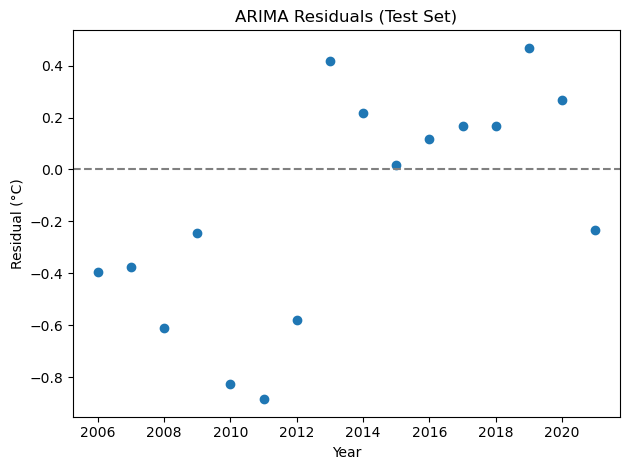

In [175]:
# Residuals and plotting
residuals_arima = y_test - y_pred_arima

plt.Figure(figsize=(12, 6))
plt.scatter(test.index.year.values.reshape(-1, 1), residuals_arima)
plt.axhline(0, color="gray", linestyle="--")
plt.title("ARIMA Residuals (Test Set)")
plt.xlabel("Year")
plt.ylabel("Residual (°C)")
plt.tight_layout()
plt.show()

#### 📊 ARIMA Model Results

The ARIMA model produced an RMSE that reflects the average prediction error in °C—lower values indicate more accurate forecasts. The R² value shows how much of the year-to-year temperature variation is explained by the model; values closer to 1 are better, while values near 0 or negative indicate a poor fit. The residuals plot displays the difference between actual and predicted temperatures for each year. Ideally, residuals should be randomly scattered around zero; patterns or large deviations suggest the model is missing some structure in the data.

In [185]:
# Polynomial Regression model
from sklearn.preprocessing import PolynomialFeatures

degree = 2  # Degree 2 better after testing Degree 3 too

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression().fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [184]:
# Metrics
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Poly deg {degree} Test RMSE: {rmse_poly:.3f}")
print(f"Poly deg {degree} Test R2: {r2_poly:.3f}")

Poly deg 2 Test RMSE: 0.381
Poly deg 2 Test R2: 0.197


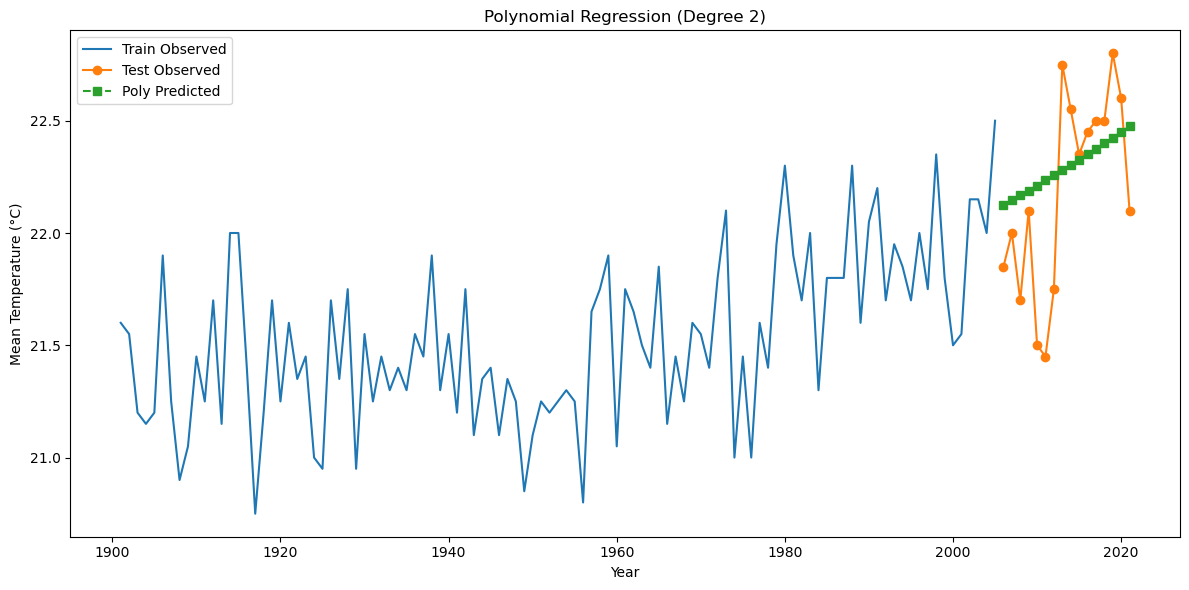

In [ ]:
# Plotting Polynomial Regression predictions
plt.figure(figsize=(12,6))
plt.plot(train.index.year, y_train, label="Train Observed")
plt.plot(test.index.year, y_test, marker="o", label="Test Observed")
plt.plot(test.index.year, y_pred_poly, marker="s", linestyle='--', label="Poly Predicted")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.title(f"Polynomial Regression (Degree {degree})")
plt.tight_layout()
plt.show()

#### 📊 Polynomial Regression (Degree 2) Results

The degree 2 polynomial regression model achieved an RMSE of **0.381 °C** and an R² of **0.197** on the test set. This means the model’s average prediction error is similar to previous models, and it explains about 20% of the year-to-year temperature variation. The plot shows that while the polynomial model can capture some curvature in the trend, it still misses much of the variability in annual temperatures.

In [186]:
# Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

df = final_temp_df.copy()

X = df.index.year.values.reshape(-1, 1)
y = df["Mean_Temperature"].values 

split_year = 2005
X_train_rf = X[df.index.year <= split_year]
y_train_rf = y[df.index.year <= split_year]
X_test_rf = X[df.index.year > split_year]
y_test_rf = y[df.index.year > split_year]

In [187]:
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train_rf, y_train_rf)
y_pred_rf = random_forest.predict(X_test_rf)
# Metrics for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf = r2_score(y_test_rf, y_pred_rf)
print(f"Random Forest Test RMSE: {rmse_rf:.3f}")
print(f"Random Forest Test R2: {r2_rf:.3f}")

Random Forest Test RMSE: 0.444
Random Forest Test R2: -0.091


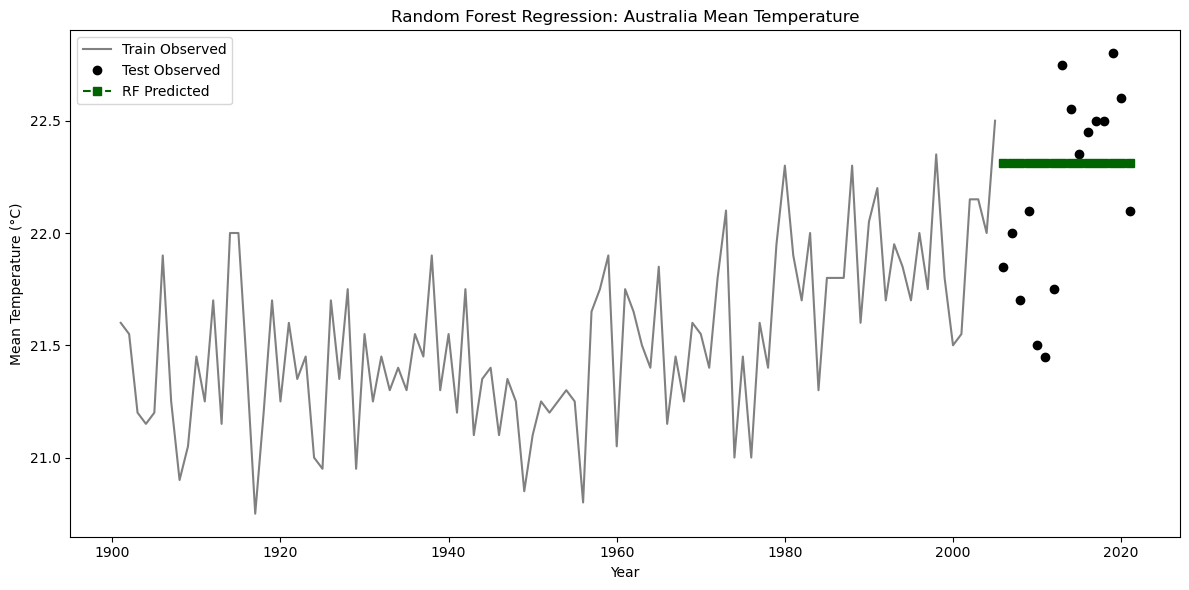

In [188]:
# Plotting Actual vs Predicted for Random Forest
plt.figure(figsize=(12,6))
plt.plot(X_train, y_train, label="Train Observed", color="gray")
plt.plot(X_test, y_test, 'o', label="Test Observed", color="black")
plt.plot(X_test, y_pred_rf, 's--', label="RF Predicted", color="darkgreen")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.title("Random Forest Regression: Australia Mean Temperature")
plt.legend()
plt.tight_layout()
plt.show()

#### 📊 Random Forest Regression Results

The Random Forest model gave an RMSE of **0.444 °C** and an R² of **-0.091** on the test set. This means its average prediction error is higher than other models, and the negative R² indicates it performs worse than simply predicting the mean. The plot shows that the model does not capture the year-to-year temperature trend well, with predictions often missing the actual values.

In [190]:
# Let's back to ARIMA model, but checking the best parameters
from pmdarima import auto_arima

auto_arima_model = auto_arima(train["Mean_Temperature"], seasonal=False, stepwise=True, trace=True)
print(auto_arima_model.summary())

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject